In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.optim.lr_scheduler as lr_scheduler
import torch.optim.adam as adam
from torch.optim.optimizer import Optimizer
import tqdm
import copy
import numpy as np
from matplotlib import pyplot as plt

cuda_available = 'enable' if torch.cuda.is_available() else 'disable'
print(torch.__version__, f'\tcuda is {cuda_available}')

2.0.0+cu118 	cuda is enable


In [23]:
root = '.data'

pretrained_size = 224
pretrained_means = [0.485, 0.456, 0.406]
pretrained_stds = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([transforms.Resize(pretrained_size),
                           transforms.RandomRotation(5),
                           transforms.RandomHorizontalFlip(0.5),
                           transforms.RandomCrop(pretrained_size, padding=10),
                           transforms.ToTensor(),
                           transforms.Normalize(mean=pretrained_means,
                                                std=pretrained_stds)])

train_data = datasets.CIFAR10(root,
                              train=True,
                              download=True,
                              transform=train_transforms)

Files already downloaded and verified


In [24]:
def calc_acc(y, y_prob) -> float:
    label_pred = y_prob.argmax(dim=1)
    correct_num = y.eq(label_pred).sum().item()
    
    return correct_num / y.shape[0]

In [25]:
class VGGConvNet(nn.Module):
    def __init__(self, config, in_channels=3):
        super().__init__()
        
        seq_list = list()
        for conf in config:
            assert len(conf) == 2 or conf == 'm'
            if conf == 'm':
                seq_list.append(nn.MaxPool2d(kernel_size=2, stride=2, padding=0))
            else:
                seq_list.append(nn.Conv2d(in_channels, conf[0], conf[1], padding=1))
                in_channels = conf[0]
                # inplace设置为True将输出直接覆盖到输入上，可以加快运算速度
                seq_list.append(nn.BatchNorm2d(conf[0]))
                seq_list.append(nn.ReLU(inplace=True))
        
        self.sequential = nn.Sequential(*seq_list)
        return
    
    def forward(self, x):
        x = self.sequential(x)
        return x
    

class VGGFCNet(nn.Module):
    def __init__(self, config, in_shape):
        super().__init__()
        in_channels = in_shape[0] * in_shape[1] * in_shape[1]
        seq_list = []
        for conf in config[:-1]:
            # print(conf)
            seq_list.append(nn.Linear(in_channels, conf))
            seq_list.append(nn.ReLU(inplace=True))
            seq_list.append(nn.Dropout(0.5))
            in_channels = conf
        
        seq_list.append(nn.Linear(in_channels, config[-1]))
        self.sequential = nn.Sequential(*seq_list)
        return
    
    def forward(self, x: torch.Tensor):
        x = x.view(x.shape[0], -1)
        x = self.sequential(x)
        return x


class VGGNet(nn.Module):
    def __init__(self, conv_config, fc_config, in_channels=3):
        super().__init__()
        assert isinstance(conv_config[-2], list) and len(conv_config[-2]) == 2
        self.conv_net = VGGConvNet(conv_config, in_channels)
        self.avg_pool = nn.AdaptiveAvgPool2d(output_size=7)
        self.fc_net = VGGFCNet(fc_config, in_shape=[conv_config[-2][0], 7, 7])
        
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.epochs_trained = 0
        
        return
    
    def forward(self, x):
        x = self.conv_net(x)
        x = self.avg_pool(x)
        x = self.fc_net(x)
        
        prob_x = F.softmax(x, 1)
        return x, prob_x
    
    def weight_num(self):
        n_params = 0
        for param in self.parameters():
            num = 1
            for shape in param.data.shape:
                num *= shape                
            n_params += num
        
        return n_params
    
    def train_(self, data_iterator, optimizer: Optimizer, loss_fn, epochs: int):    
        self.train()
        
        for epoch in range(epochs):
            loop = tqdm.tqdm(data_iterator, total=len(data_iterator))
            
            for image, label in loop:
                optimizer.zero_grad()
                
                image = image.to(self.device)
                label = label.to(self.device)
                label_pred, label_prob = self(image)
                loss = loss_fn(label_pred, label)
                
                loss.backward()
                optimizer.step()
                
                self.epochs_trained += 1
                loop.set_description(f'Epochs: {epoch} / {epochs}, total: {self.epochs_trained}')
                loop.set_postfix({'loss': f'{loss.item()}', 'acc': f'{calc_acc(y=label, y_prob=label_prob)}'})
                loop.update()
        
        return

In [26]:
conv_config = [[64, 3], 'm',
          [128, 3], 'm',
          [256, 3], [256, 3], 'm',
          [512, 3], [512, 3], 'm', 
          [512, 3], [512, 3], 'm']
fc_config = [4096, 4096, 10]

In [27]:
model = VGGNet(conv_config, fc_config)
model.to('cuda')
print(model)
print(f'weight num is {model.weight_num():,}')

VGGNet(
  (conv_net): VGGConvNet(
    (sequential): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [32]:
import torchvision
pretrained_weight = torch.load('./vgg11_bn-6002323d.pth')
pretrained_model = torchvision.models.vgg11_bn(weights=None)
pretrained_model.load_state_dict(pretrained_weight)
print(pretrained_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [8]:
def copy_weight(src: nn.Module, dst: nn.Module):
    with torch.no_grad():
        for param, pretrained_param in zip(dst.parameters(), src.parameters()):
            param.copy_(pretrained_param)
    
    return

In [9]:
import torch.utils.data

batch_size = 128
train_iterator = torch.utils.data.DataLoader(train_data, batch_size, shuffle=True)

In [10]:
class IteratorWrapper:
    def __init__(self, iterator_like):
        self.iterator_like = iterator_like
        self.iterator = iter(self.iterator_like)
        return
    
    def __next__(self):
        try:
            return next(self.iterator)
        except StopIteration:
            self.iterator = iter(self.iterator_like)
            return next(self.iterator)
        
    def __len__(self):
        return len(self.iterator_like)
    
    def __iter__(self):
        return iter(self.iterator_like)

In [11]:
train_iterator = torch.utils.data.DataLoader(train_data, batch_size, shuffle=True)
train_iterator = IteratorWrapper(train_iterator)

In [12]:
class LRFinder:
    def __init__(self, model, optimizer: Optimizer, loss_fn, lr_range, device='cuda'):
        self.model = copy.deepcopy(model).to(device)
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler.ExponentialLR(self.optimizer, np.power(lr_range[1] / lr_range[0], 1e-2))
        self.loss_fn = loss_fn.to(device)
        self.device = device
        
        return
    
    def range_test(self, test_data, epochs):
        loss_list = list()
        lr_list = list()
        
        pbar = tqdm.tqdm()
        for epoch in tqdm.trange(epochs):
            image, label = next(test_data)
            image = image.to(self.device)
            label = label.float()
            label = label.to(self.device)
            
            self.optimizer.zero_grad()
            pred_label, _ = self.model(image)
            loss = self.loss_fn(pred_label, label)
            loss.backward()
            
            self.optimizer.step()
            self.lr_scheduler.step()
            
            pbar.set_postfix(loss=loss.item())
            loss_list.append(loss.item())
            lr_list.append(self.lr_scheduler.get_last_lr())
            
        return loss_list, lr_list

In [34]:
found_lr = 5e-4

model = VGGNet(conv_config, fc_config)
model.to('cuda')
copy_weight(src=pretrained_model.features, dst=model.conv_net)
copy_weight(src=pretrained_model.classifier[:-1], dst=model.fc_net)
optimizer = adam.Adam([{'params': model.conv_net.parameters(), 'lr': found_lr / 10},
                       {'params': model.fc_net.parameters()}], lr=found_lr)

In [ ]:
model.train_(train_iterator, optimizer, nn.CrossEntropyLoss(), 1)

Epochs: 0 / 1, total: 96:  28%|██▊       | 110/391 [22:14<59:17, 12.66s/it, loss=0.5951306223869324, acc=0.8046875]   

In [35]:
print(next(pretrained_model.parameters()))

Parameter containing:
tensor([[[[-5.9550e-01, -8.3957e-01, -5.1592e-01],
          [ 4.3290e-02, -5.4894e-02, -1.9865e-01],
          [ 6.0978e-01,  9.1177e-01,  6.1916e-01]],

         [[-9.0904e-01, -1.3191e+00, -8.8276e-01],
          [ 7.5378e-02,  6.8023e-03, -1.9233e-01],
          [ 8.9835e-01,  1.3841e+00,  9.1575e-01]],

         [[-3.8599e-01, -6.1602e-01, -3.4967e-01],
          [ 1.3486e-02,  3.0266e-02, -1.0543e-01],
          [ 3.4950e-01,  6.8686e-01,  3.9954e-01]]],


        [[[ 1.0105e-05, -5.7597e-07,  3.7357e-05],
          [ 2.3276e-05, -2.6341e-05,  2.4588e-05],
          [ 3.2592e-05, -8.7637e-06,  1.0022e-05]],

         [[-5.1987e-06, -1.5983e-05,  3.5566e-05],
          [ 1.8771e-05, -3.9012e-05,  2.3113e-05],
          [ 3.8826e-05, -8.0352e-06,  1.5741e-05]],

         [[-2.1435e-06, -9.3418e-06,  2.5209e-05],
          [ 1.3776e-05, -3.0619e-05,  1.3845e-05],
          [ 2.6642e-05, -9.2021e-06,  6.2266e-06]]],


        [[[ 1.8067e-01,  2.5138e-01,  1.2015

In [14]:
model.load_state_dict(torch.load('model.pt'))
model.to('cuda')

VGGNet(
  (conv_net): VGGConvNet(
    (sequential): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [15]:
found_lr = 5e-4
optimizer = adam.Adam([{'params': model.conv_net.parameters(), 'lr': found_lr / 10},
                       {'params': model.fc_net.parameters()}], lr=found_lr)
model.train_(train_iterator, optimizer, nn.CrossEntropyLoss(), 1)
torch.save(model.state_dict(), 'model1.pt')

Epochs: 0 / 1, total: 391: 100%|██████████| 391/391 [1:14:37<00:00, 11.45s/it, loss=1.8994379043579102, acc=0.2875]   


In [ ]:
model.train_(train_iterator, optimizer, nn.CrossEntropyLoss(), 1)

In [14]:
torch.save(model.state_dict(), 'model.pt')

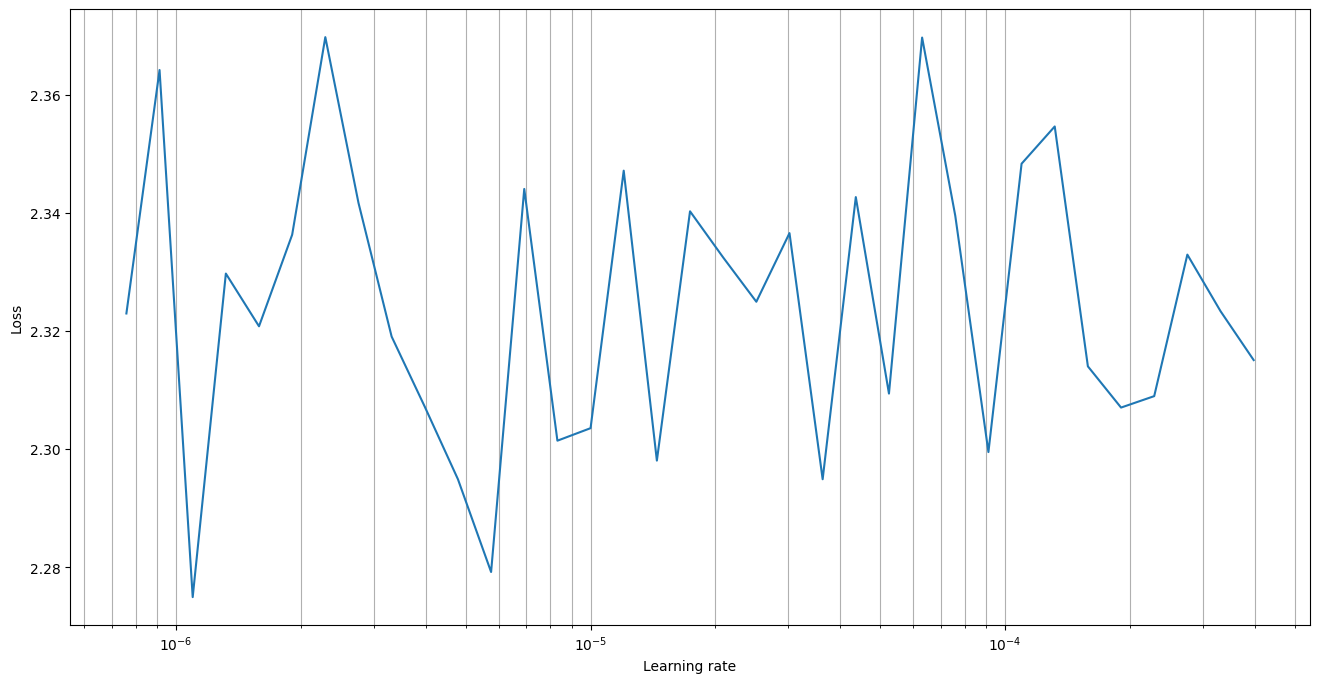

In [19]:
def plot_lr_finder(lrs, losses, skip_start=5, skip_end=5):

    if skip_end == 0:
        lrs = lrs[skip_start:]
        losses = losses[skip_start:]
    else:
        lrs = lrs[skip_start:-skip_end]
        losses = losses[skip_start:-skip_end]

    fig = plt.figure(figsize=(16, 8))
    ax = fig.add_subplot(1, 1, 1)
    ax.plot(lrs, losses)
    ax.set_xscale('log')
    ax.set_xlabel('Learning rate')
    ax.set_ylabel('Loss')
    ax.grid(True, 'both', 'x')
    plt.show()

In [ ]:
out_size = 7
a = torch.rand([10, 1, 256, 256])
avg_pool = nn.AdaptiveAvgPool2d(output_size=out_size)
linear = nn.Linear(out_size ** 2, 5)
b = avg_pool(a)
print(b.shape)

In [ ]:
a = a.view(a.shape[0], -1)
print(a.shape)